<a href="https://colab.research.google.com/github/nemoiitkgp/FWI-Codes-PhD/blob/main/BP_2007_Data_Recovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nbconvert
!jupyter nbconvert --to notebook --ClearMetadataPreprocessor.enabled=True \
  --ClearMetadataPreprocessor.preserve_nb_metadata_mask='{"language_info"}' \
  BP_2007_Data_Recovery.ipynb --output BP_2007_Data_Recovery.ipynb

[NbConvertApp] WARNING | pattern 'BP_2007_Data_Recovery.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--e

  ✓ Already downloaded: Anisotropic_FD_Model_Shots_part1.sgy.gz
  ✓ Already downloaded: Anisotropic_FD_Model_Shots_part2.sgy.gz
  ✓ Already downloaded: Anisotropic_FD_Model_Shots_part3.sgy.gz
  ✓ Already downloaded: Anisotropic_FD_Model_Shots_part4.sgy.gz
  ✓ Already downloaded: Anisotropic_FD_Model_VSP.tar.gz
  ✓ Already downloaded: DatasetInformation_And_Disclaimer.txt
  ✓ Already downloaded: ModelParams.tar.gz
  ✓ Already downloaded: OtherFiles-2.tar.gz
  ✓ Already downloaded: README_Modification.txt

All downloads complete.

Extracting compressed files …
  ✓ Already extracted: Anisotropic_FD_Model_Shots_part1.sgy
  ✓ Already extracted: Anisotropic_FD_Model_Shots_part2.sgy
  ✓ Already extracted: Anisotropic_FD_Model_Shots_part3.sgy
  ✓ Already extracted: Anisotropic_FD_Model_Shots_part4.sgy
  ✓ Already extracted: Anisotropic_FD_Model_VSP.tar.gz
  ✓ Already extracted: ModelParams.tar.gz
  ✓ Already extracted: OtherFiles-2.tar.gz

Extraction complete.

Model SEG-Y files found:
  Model

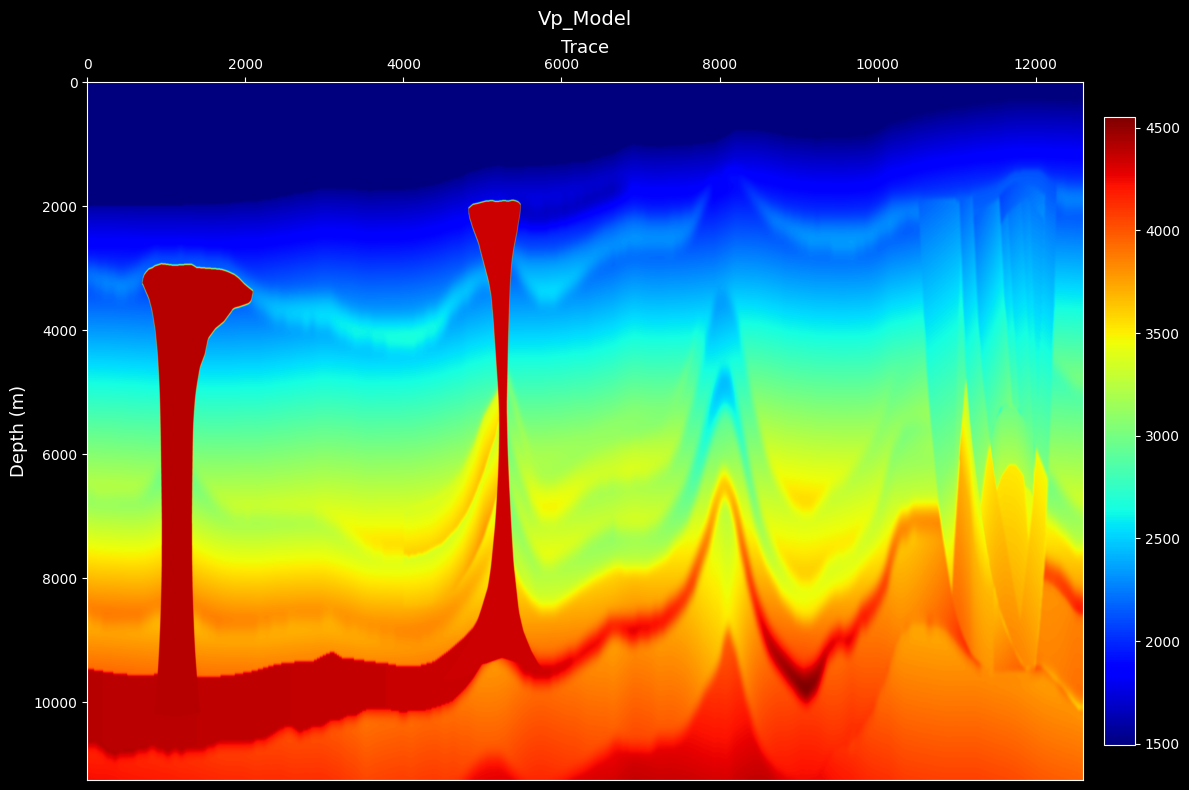

Saved: Vp_Model_BP2007.png

=== Building QC Shots gather (all 4 parts) ===
  Reading part 1: Anisotropic_FD_Model_Shots_part1.sgy
  Reading part 2: Anisotropic_FD_Model_Shots_part2.sgy
  Reading part 3: Anisotropic_FD_Model_Shots_part3.sgy
  Reading part 4: Anisotropic_FD_Model_Shots_part4.sgy
  Shape after clipping: 1125 time samples × 4000 traces
  Time range: 0 – 8.99 s


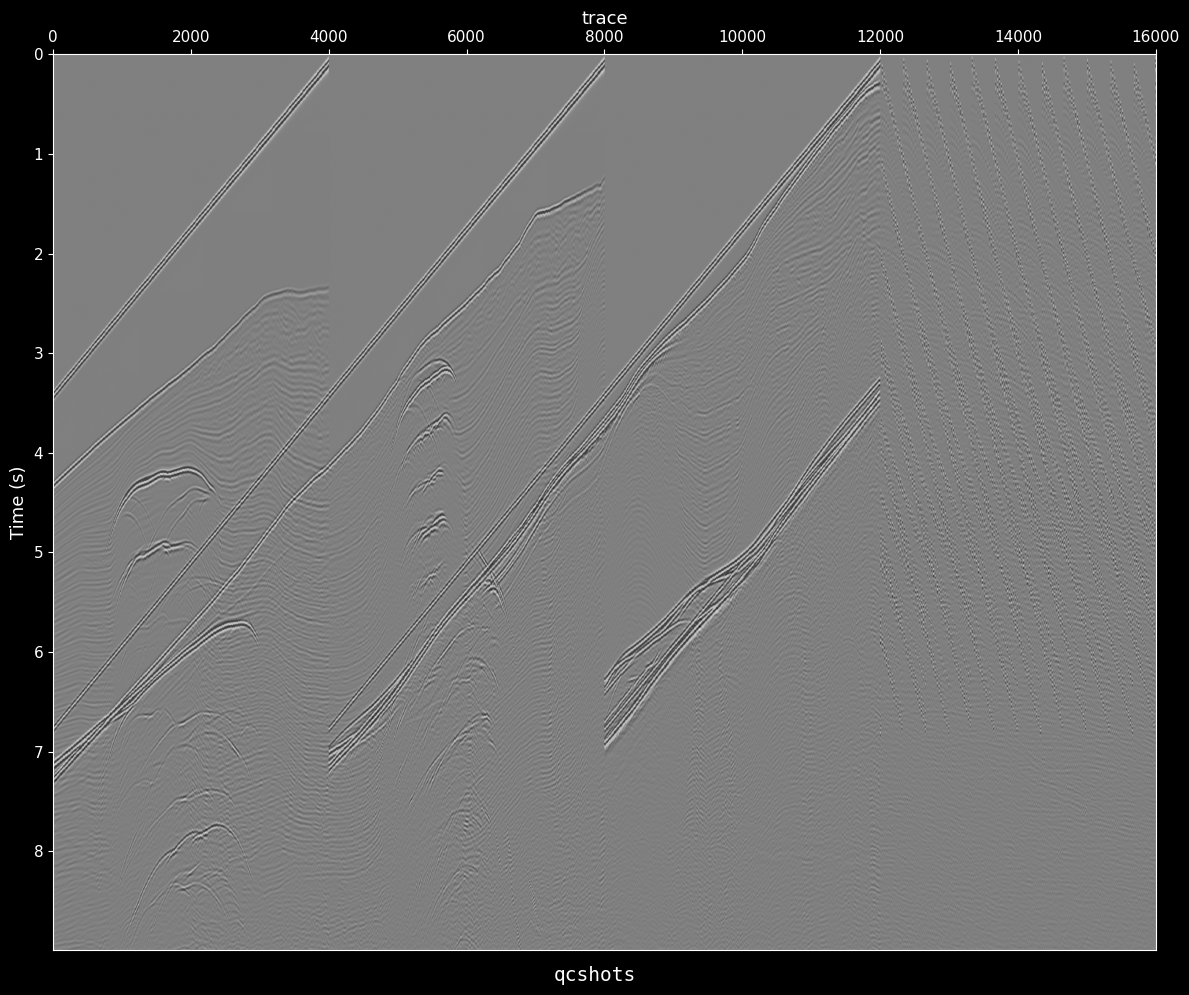

Saved: QCShots_BP2007.png

=== Building NTG (Near-Trace Gather) ===
  Reading near-traces from part 1: Anisotropic_FD_Model_Shots_part1.sgy
  Reading near-traces from part 2: Anisotropic_FD_Model_Shots_part2.sgy
  Reading near-traces from part 3: Anisotropic_FD_Model_Shots_part3.sgy
  Reading near-traces from part 4: Anisotropic_FD_Model_Shots_part4.sgy
  NTG shape: 1125 × 13077 (time × traces)


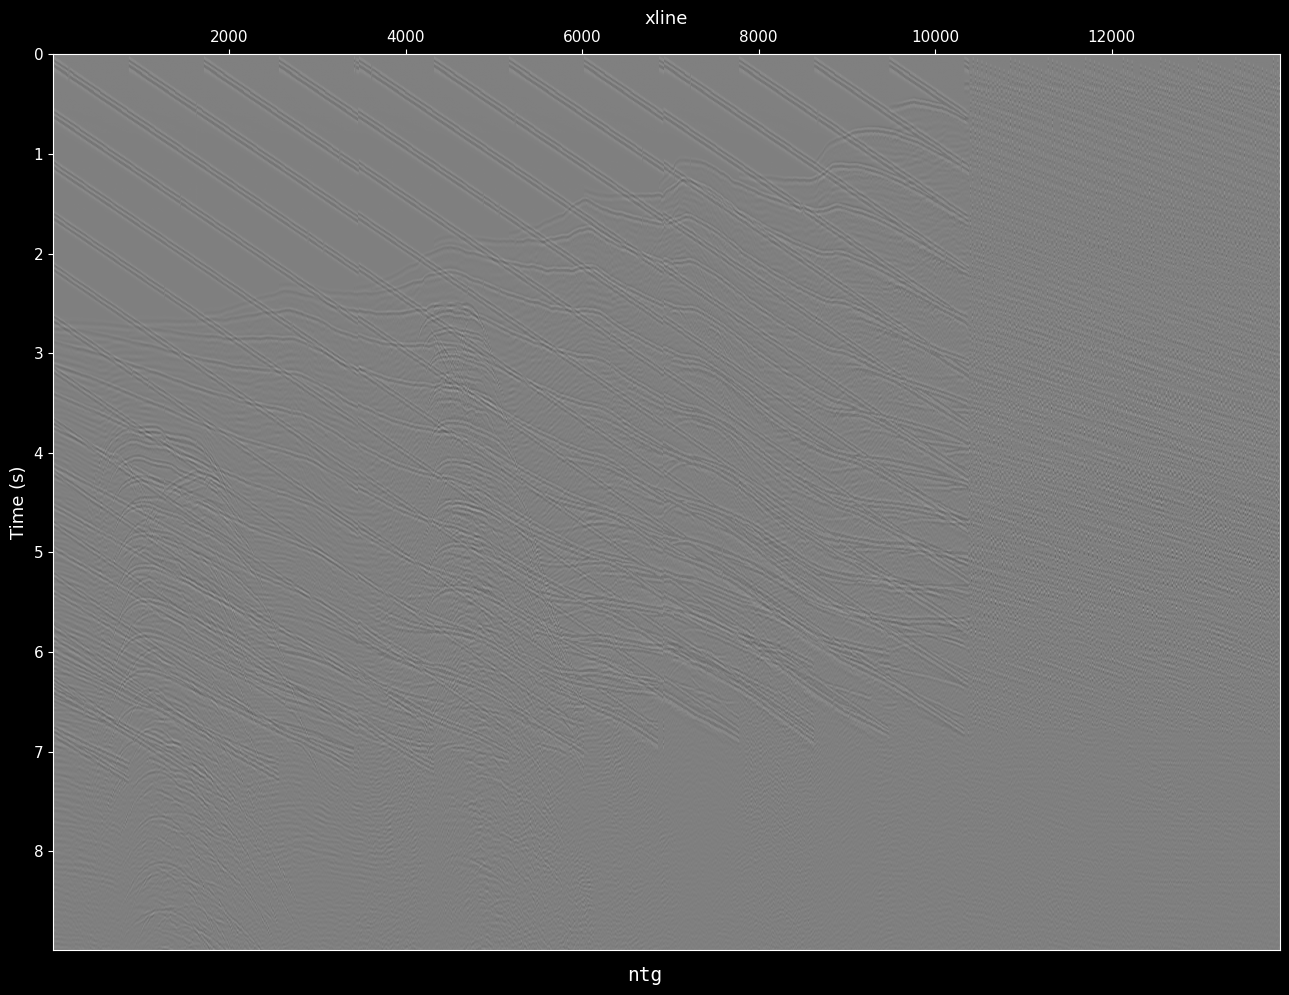

Saved: NTG_BP2007.png

=== Shot Gather Preview (Part 1, first 200 traces) ===


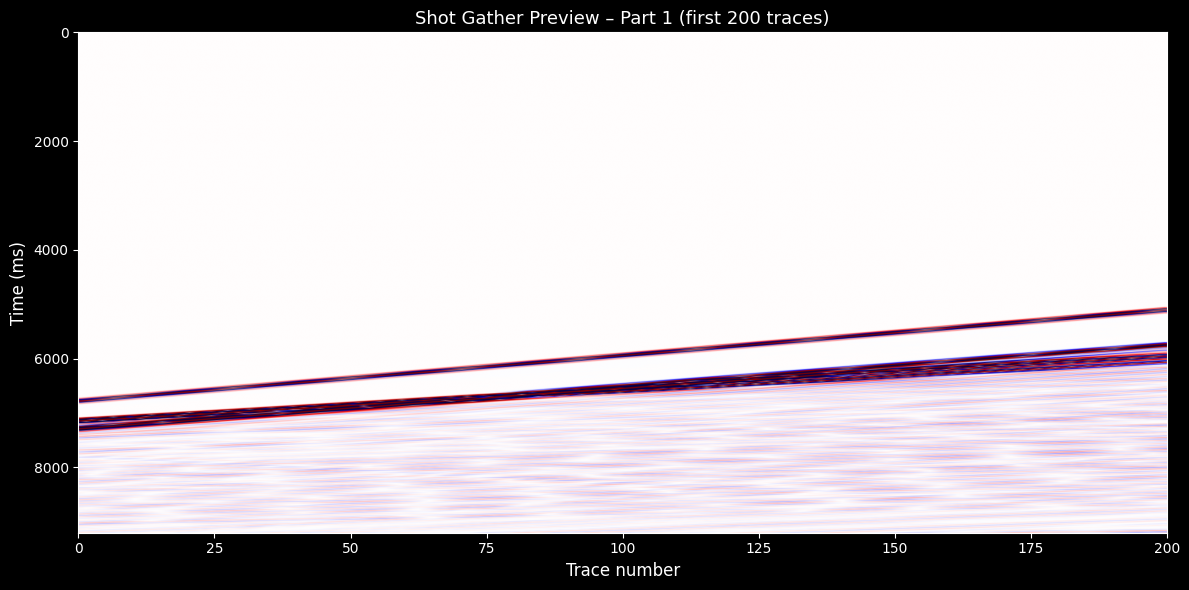

Saved: ShotGather_Preview_BP2007.png

All plots saved:
  • Vp_Model_BP2007.png         – velocity model
  • QCShots_BP2007.png          – qcshots gather (Image 1 style)
  • NTG_BP2007.png              – near-trace gather (Image 2 style)
  • ShotGather_Preview_BP2007.png – seismic shot preview


In [2]:
# ============================================================
# 2007 BP Anisotropic Velocity Benchmark – Download, Extract & Plot
# Produces: Vp model + QC shots + NTG gather (matching reference images)
# Designed for Google Colab
# ============================================================

# ── CELL 1 ─ Install dependencies ───────────────────────────
!pip install segyio matplotlib numpy tqdm

# ── CELL 2 ─ Imports ────────────────────────────────────────
import os
import gzip
import tarfile
import shutil
import urllib.request
from pathlib import Path
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import segyio

# ── CELL 3 ─ Download helpers ────────────────────────────────
BASE_URL = "http://s3.amazonaws.com/open.source.geoscience/open_data/bptti2007/"

FILES = {
    "shots_part1":  "Anisotropic_FD_Model_Shots_part1.sgy.gz",
    "shots_part2":  "Anisotropic_FD_Model_Shots_part2.sgy.gz",
    "shots_part3":  "Anisotropic_FD_Model_Shots_part3.sgy.gz",
    "shots_part4":  "Anisotropic_FD_Model_Shots_part4.sgy.gz",
    "vsp":          "Anisotropic_FD_Model_VSP.tar.gz",
    "disclaimer":   "DatasetInformation_And_Disclaimer.txt",
    "model_params": "ModelParams.tar.gz",
    "other_files":  "OtherFiles-2.tar.gz",
    "readme":       "README_Modification.txt",
}

DATA_DIR = Path("bp2007_data")
DATA_DIR.mkdir(exist_ok=True)


class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)


def download_file(url: str, dest: Path) -> Path:
    """Download a single file with a progress bar; skip if already present."""
    if dest.exists():
        print(f"  ✓ Already downloaded: {dest.name}")
        return dest
    print(f"  ↓ Downloading: {dest.name}")
    with DownloadProgressBar(unit="B", unit_scale=True, miniters=1, desc=dest.name) as t:
        urllib.request.urlretrieve(url, dest, reporthook=t.update_to)
    return dest


def extract_gz(gz_path: Path) -> Path:
    """Decompress a .sgy.gz file → .sgy (same directory)."""
    out_path = gz_path.with_suffix("")   # removes .gz
    if out_path.exists():
        print(f"  ✓ Already extracted: {out_path.name}")
        return out_path
    print(f"   Extracting: {gz_path.name}")
    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    return out_path


def extract_tar(tar_path: Path, extract_dir: Path) -> Path:
    """Extract a .tar.gz archive into extract_dir."""
    if extract_dir.exists():
        print(f"  ✓ Already extracted: {tar_path.name}")
        return extract_dir
    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"   Extracting: {tar_path.name}")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=extract_dir)
    return extract_dir


# ── CELL 4 ─ Download all files ─────────────────────────────
print("=" * 60)
print("Downloading 2007 BP Anisotropic Velocity Benchmark data")
print("=" * 60)

downloaded = {}
for key, filename in FILES.items():
    url  = BASE_URL + filename
    dest = DATA_DIR / filename
    downloaded[key] = download_file(url, dest)

print("\nAll downloads complete.\n")

# ── CELL 5 ─ Extract archives ────────────────────────────────
print("Extracting compressed files …")

sgy_files = []
for i in range(1, 5):
    key = f"shots_part{i}"
    gz  = downloaded[key]
    sgy = extract_gz(gz)
    sgy_files.append(sgy)

vsp_dir   = extract_tar(downloaded["vsp"],          DATA_DIR / "VSP")
model_dir = extract_tar(downloaded["model_params"], DATA_DIR / "ModelParams")
other_dir = extract_tar(downloaded["other_files"],  DATA_DIR / "OtherFiles")

print("\nExtraction complete.\n")

# ── CELL 6 ─ Helper: find SEG-Y files ───────────────────────
def find_segy_files(directory: Path):
    """Recursively find all .segy / .sgy files."""
    return list(directory.rglob("*.segy")) + list(directory.rglob("*.sgy"))


def find_model_file(directory: Path, keywords=("Vp", "vp", "VP", "velocity", "Velocity")):
    for kw in keywords:
        matches = list(directory.rglob(f"*{kw}*"))
        if matches:
            return matches[0]
    all_segy = find_segy_files(directory)
    return all_segy[0] if all_segy else None


# ── CELL 7 ─ Plot Vp model ───────────────────────────────────
model_segy_files = find_segy_files(model_dir)
print("Model SEG-Y files found:")
for f in model_segy_files:
    print(" ", f.relative_to(DATA_DIR))

vp_file = find_model_file(model_dir)
if vp_file is None:
    raise FileNotFoundError(
        "Could not find a Vp model SEG-Y file inside ModelParams. "
        "Please inspect DATA_DIR / 'ModelParams' and set vp_file manually."
    )

print(f"\nUsing Vp model file: {vp_file.name}")

with segyio.open(str(vp_file), ignore_geometry=True) as f:
    vp_data = segyio.collect(f.trace[:]).T   # (n_samples, n_traces)
    dt_us   = f.bin[segyio.BinField.Interval]
    dz_m    = dt_us / 1e6 * 1000

n_depth, n_traces = vp_data.shape
depth_axis = np.arange(n_depth) * dz_m
trace_axis = np.arange(n_traces)

print(f"  Shape   : {n_depth} depth samples × {n_traces} traces")
print(f"  Vp range: {vp_data.min():.0f} – {vp_data.max():.0f} m/s")

fig, ax = plt.subplots(figsize=(12, 8), facecolor="black")
ax.set_facecolor("black")
im = ax.imshow(
    vp_data, aspect="auto", cmap="jet", origin="upper",
    extent=[trace_axis[0], trace_axis[-1], depth_axis[-1], depth_axis[0]],
    interpolation="bilinear", vmin=vp_data.min(), vmax=vp_data.max(),
)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("white")
ax.tick_params(colors="white", which="both")
for spine in ax.spines.values():
    spine.set_edgecolor("white")
ax.set_xlabel("Trace",     color="white", fontsize=13)
ax.set_ylabel("Depth (m)", color="white", fontsize=13)
ax.set_title("Vp_Model",   color="white", fontsize=14, pad=10)
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()
ax.tick_params(axis="x", colors="white")
plt.tight_layout()
plt.savefig("Vp_Model_BP2007.png", dpi=150, bbox_inches="tight",
            facecolor="black", edgecolor="black")
plt.show()
print("Saved: Vp_Model_BP2007.png")


# ═══════════════════════════════════════════════════════════════
# ── CELL 8 ─ QC SHOTS PLOT  (matches Image 1 / "qcshots") ────
# ═══════════════════════════════════════════════════════════════
# Strategy: concatenate the first N traces from EVERY part file
# so the full ~4000-trace extent shown in the reference is covered.
# We read a uniform stride across each file to keep memory reasonable.
# ───────────────────────────────────────────────────────────────

print("\n=== Building QC Shots gather (all 4 parts) ===")

# --- Parameters you can tune ---
TRACES_PER_PART  = 1000   # traces sampled from each part file (4 × 1000 = 4000 total)
MAX_TIME_S       = 9.0    # clip display to 9 s (matching reference)
# --------------------------------

def read_traces_strided(sgy_path: Path, n_want: int):
    """
    Open a SEG-Y, read `n_want` evenly-spaced traces, return (data, dt_s).
    data shape: (n_samples, n_want)
    """
    with segyio.open(str(sgy_path), ignore_geometry=True) as f:
        total   = f.tracecount
        dt_s    = f.bin[segyio.BinField.Interval] / 1e6
        n_samp  = len(f.trace[0])
        indices = np.linspace(0, total - 1, min(n_want, total), dtype=int)
        data    = np.zeros((n_samp, len(indices)), dtype=np.float32)
        for col, idx in enumerate(indices):
            data[:, col] = f.trace[int(idx)]
    return data, dt_s

parts_data = []
dt_shot    = None

for i, sgy_path in enumerate(sgy_files):
    print(f"  Reading part {i+1}: {sgy_path.name}")
    d, dt = read_traces_strided(sgy_path, TRACES_PER_PART)
    parts_data.append(d)
    if dt_shot is None:
        dt_shot = dt

# Concatenate all parts along the trace axis → (n_samples, ~4000)
qcshots = np.concatenate(parts_data, axis=1)
n_samp_total = qcshots.shape[0]

# Build time axis and clip to MAX_TIME_S
t_axis_full = np.arange(n_samp_total) * dt_shot          # seconds
clip_idx    = np.searchsorted(t_axis_full, MAX_TIME_S)
qcshots     = qcshots[:clip_idx, :]
t_axis      = t_axis_full[:clip_idx]
n_traces_qc = qcshots.shape[1]

print(f"  Shape after clipping: {qcshots.shape[0]} time samples × {n_traces_qc} traces")
print(f"  Time range: 0 – {t_axis[-1]:.2f} s")

# Normalise with a gentle clip (98th percentile) – identical to standard seismic display
clip_val = np.percentile(np.abs(qcshots), 98)
if clip_val == 0:
    clip_val = 1.0

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10), facecolor="black")
ax.set_facecolor("black")

ax.imshow(
    qcshots,
    aspect="auto",
    cmap="gray",           # matches reference: gray-scale wiggle-trace style
    origin="upper",
    vmin=-clip_val,
    vmax= clip_val,
    extent=[0, n_traces_qc * 4, t_axis[-1], t_axis[0]],   # scale x to ~4000-trace range
    interpolation="bilinear",
)

# Axis style – white on black, top x-axis, matching reference exactly
ax.tick_params(colors="white", which="both", labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor("white")

ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()
ax.tick_params(axis="x", colors="white")

ax.set_xlabel("trace",    color="white", fontsize=13)
ax.set_ylabel("Time (s)", color="white", fontsize=13)

# Title at bottom (matching "qcshots" label in reference image)
ax.set_title("")
fig.text(0.5, 0.01, "qcshots", ha="center", va="bottom",
         color="white", fontsize=14, fontfamily="monospace")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("QCShots_BP2007.png", dpi=150, bbox_inches="tight",
            facecolor="black", edgecolor="black")
plt.show()
print("Saved: QCShots_BP2007.png")


# ═══════════════════════════════════════════════════════════════
# ── CELL 9 ─ NTG (Near-Trace Gather) PLOT  (matches Image 2) ─
# ═══════════════════════════════════════════════════════════════
# The "ntg" panel in the reference shows a large x-line extent
# (~13 000 traces) and looks like a full-offset or near-trace
# gather / stack across ALL parts concatenated.
# We read one trace every ~3 traces from the full dataset so
# the x-axis reaches the ~13 000 xline scale in the reference.
# ───────────────────────────────────────────────────────────────

print("\n=== Building NTG (Near-Trace Gather) ===")

# --- Parameters ---
TOTAL_NTG_TRACES = 13_000   # target width to match reference x-axis
# ------------------

def read_all_headers_and_near(sgy_path: Path, near_offset_max: float = 200.0):
    """
    Read traces from a SEG-Y whose absolute offset header is ≤ near_offset_max.
    Falls back to reading every Nth trace if no offset header is set.
    Returns (data, dt_s, xline_numbers).
    """
    with segyio.open(str(sgy_path), ignore_geometry=True) as f:
        dt_s    = f.bin[segyio.BinField.Interval] / 1e6
        total   = f.tracecount
        n_samp  = len(f.trace[0])

        # Try to read offset and xline from trace headers
        offsets = np.array([f.header[i][segyio.TraceField.offset]
                            for i in range(total)], dtype=np.float32)
        xlines  = np.array([f.header[i][segyio.TraceField.CROSSLINE_3D]
                            for i in range(total)], dtype=np.int32)

        # Select near-offset traces; if all offsets are 0 (unset) keep everything
        if offsets.max() > 0:
            mask = np.abs(offsets) <= near_offset_max
        else:
            # No offset info – take every Nth to spread evenly
            N    = max(1, total // (TOTAL_NTG_TRACES // len(sgy_files)))
            mask = np.zeros(total, dtype=bool)
            mask[::N] = True

        indices = np.where(mask)[0]
        data    = np.zeros((n_samp, len(indices)), dtype=np.float32)
        for col, idx in enumerate(indices):
            data[:, col] = f.trace[int(idx)]

    return data, dt_s, xlines[indices] if xlines.max() != 0 else indices


ntg_parts  = []
xline_nums = []
dt_ntg     = None

for i, sgy_path in enumerate(sgy_files):
    print(f"  Reading near-traces from part {i+1}: {sgy_path.name}")
    d, dt, xl = read_all_headers_and_near(sgy_path)
    ntg_parts.append(d)
    xline_nums.append(xl)
    if dt_ntg is None:
        dt_ntg = dt

ntg_data   = np.concatenate(ntg_parts,  axis=1)   # (n_samples, n_near_traces)
xline_all  = np.concatenate(xline_nums, axis=0)

# Clip to MAX_TIME_S
t_full_ntg = np.arange(ntg_data.shape[0]) * dt_ntg
clip_ntg   = np.searchsorted(t_full_ntg, MAX_TIME_S)
ntg_data   = ntg_data[:clip_ntg, :]
t_ntg      = t_full_ntg[:clip_ntg]

n_samp_ntg, n_tr_ntg = ntg_data.shape
print(f"  NTG shape: {n_samp_ntg} × {n_tr_ntg} (time × traces)")

# If we ended up with more traces than TOTAL_NTG_TRACES, subsample
if n_tr_ntg > TOTAL_NTG_TRACES:
    idx_sub    = np.linspace(0, n_tr_ntg - 1, TOTAL_NTG_TRACES, dtype=int)
    ntg_data   = ntg_data[:, idx_sub]
    xline_all  = xline_all[idx_sub] if len(xline_all) == n_tr_ntg else np.arange(TOTAL_NTG_TRACES)
    n_tr_ntg   = TOTAL_NTG_TRACES

# Build x-axis: use actual xline numbers if sensible, else synthetic
if xline_all.max() > 0 and xline_all.max() < 200_000:
    x_min, x_max = int(xline_all.min()), int(xline_all.max())
else:
    x_min, x_max = 0, TOTAL_NTG_TRACES

clip_ntg_val = np.percentile(np.abs(ntg_data), 98)
if clip_ntg_val == 0:
    clip_ntg_val = 1.0

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 10), facecolor="black")
ax.set_facecolor("black")

ax.imshow(
    ntg_data,
    aspect="auto",
    cmap="gray",
    origin="upper",
    vmin=-clip_ntg_val,
    vmax= clip_ntg_val,
    extent=[x_min, x_max, t_ntg[-1], t_ntg[0]],
    interpolation="bilinear",
)

ax.tick_params(colors="white", which="both", labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor("white")

ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()
ax.tick_params(axis="x", colors="white")

ax.set_xlabel("xline",    color="white", fontsize=13)
ax.set_ylabel("Time (s)", color="white", fontsize=13)
ax.set_title("",          color="white")

fig.text(0.5, 0.01, "ntg", ha="center", va="bottom",
         color="white", fontsize=14, fontfamily="monospace")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("NTG_BP2007.png", dpi=150, bbox_inches="tight",
            facecolor="black", edgecolor="black")
plt.show()
print("Saved: NTG_BP2007.png")


# ═══════════════════════════════════════════════════════════════
# ── CELL 10 ─ (ORIGINAL) Shot-gather preview – Part 1 only ───
# ═══════════════════════════════════════════════════════════════
print("\n=== Shot Gather Preview (Part 1, first 200 traces) ===")

with segyio.open(str(sgy_files[0]), ignore_geometry=True) as f:
    n_preview = min(200, f.tracecount)
    shot_data = np.array([f.trace[i] for i in range(n_preview)]).T
    dt_shot_p = f.bin[segyio.BinField.Interval] / 1e6
    t_axis_p  = np.arange(shot_data.shape[0]) * dt_shot_p * 1000   # ms

fig3, ax3 = plt.subplots(figsize=(12, 6), facecolor="black")
ax3.set_facecolor("black")

clip3 = np.percentile(np.abs(shot_data), 98)
ax3.imshow(
    shot_data,
    aspect="auto",
    cmap="seismic",
    origin="upper",
    vmin=-clip3,
    vmax= clip3,
    extent=[0, n_preview, t_axis_p[-1], t_axis_p[0]],
    interpolation="bilinear",
)

ax3.tick_params(colors="white")
for spine in ax3.spines.values():
    spine.set_edgecolor("white")
ax3.set_xlabel("Trace number", color="white", fontsize=12)
ax3.set_ylabel("Time (ms)",    color="white", fontsize=12)
ax3.set_title("Shot Gather Preview – Part 1 (first 200 traces)",
              color="white", fontsize=13)

plt.tight_layout()
plt.savefig("ShotGather_Preview_BP2007.png", dpi=150,
            bbox_inches="tight", facecolor="black")
plt.show()
print("Saved: ShotGather_Preview_BP2007.png")

# ── Summary ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("All plots saved:")
print("  • Vp_Model_BP2007.png         – velocity model")
print("  • QCShots_BP2007.png          – qcshots gather (Image 1 style)")
print("  • NTG_BP2007.png              – near-trace gather (Image 2 style)")
print("  • ShotGather_Preview_BP2007.png – seismic shot preview")
print("=" * 60)